# BO hparam sweep analysis

This notebook visualizes the saved BO hyperparameter sweep for `exp6_bo_hparam_n20`.

The main questions are:

- Which `Q x max_radius` settings produce the best held-out `yield_r2`?
- Does `max_radius` materially change the BO trajectory, or is the local combo-subgraph already reaching `Q` before radius becomes binding?
- Do BO mechanics such as EI, GP parameters, local observations, subgraph size, and subset movement explain the observed differences?

All tables and figures are saved under `daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/`.


In [1]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Iterable

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 80)
pd.set_option("display.max_colwidth", 120)

ROOT = Path("/projects/standard/kumarv/shared/dwij/daycent")
RESULT_ROOT = ROOT / "output/selection/exp6_bo_hparam_n20/bo_graph"
REPORT_DIR = RESULT_ROOT / "hparam_sweep_n20"
REPORT_DIR.mkdir(parents=True, exist_ok=True)

EXPECTED_QS = [200, 400, 600, 800]
EXPECTED_RADII = [3, 5, 10, 15]
SCORE_METRIC = "yield_r2"

print(f"Result root: {RESULT_ROOT}")
print(f"Report dir:  {REPORT_DIR}")


Result root: /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph
Report dir:  /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20


## Load saved BO results

The sweep aggregate directory is intentionally not used as an input here because it was empty when this notebook was created. Instead, the loader reads each completed run's `*/sweep_s*/bo_results.csv` directly.


In [2]:
def load_bo_results(result_root: Path) -> tuple[pd.DataFrame, list[Path]]:
    paths = sorted(
        p for p in result_root.glob("*/sweep_s*/bo_results.csv")
        if p.parent.parent.name != "hparam_sweep_n20"
    )
    frames = []
    for path in paths:
        df_i = pd.read_csv(path)
        df_i["result_csv"] = str(path)
        df_i["run_dir"] = str(path.parent.parent)
        df_i["sweep_dir"] = str(path.parent)
        frames.append(df_i)

    if not frames:
        raise FileNotFoundError(f"No bo_results.csv files found under {result_root}")

    df = pd.concat(frames, ignore_index=True)
    numeric_cols = [
        "seed", "n_points", "Q", "max_radius", "epsilon_factor", "fail_tol",
        "succ_tol", "shrink_tol", "iteration", "score", "best_score", "ei_value",
        "gp_lengthscale", "gp_noise_var", "n_local_obs", "subgraph_size",
        "n_restarts", "n_total_obs", "elapsed_s",
    ]
    for col in numeric_cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

    df = df.sort_values(["Q", "max_radius", "seed", "iteration"], kind="mergesort").reset_index(drop=True)
    return df, paths


df, result_paths = load_bo_results(RESULT_ROOT)
combined_path = REPORT_DIR / "combined_bo_hparam_results.csv"
df.to_csv(combined_path, index=False)

print(f"Loaded {len(result_paths)} BO result CSV files")
print(f"Loaded {len(df)} iteration rows")
print(f"Combined CSV -> {combined_path}")
display(df.head())


Loaded 9 BO result CSV files
Loaded 180 iteration rows
Combined CSV -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/combined_bo_hparam_results.csv


,experiment_name,run_label,seed,n_points,Q,max_radius,epsilon_factor,fail_tol,succ_tol,shrink_tol,iteration,score,best_score,subset_signature,selected_points_json,ei_value,gp_lengthscale,gp_noise_var,n_local_obs,subgraph_size,n_restarts,n_total_obs,elapsed_s,result_csv,run_dir,sweep_dir
0,exp6_bo_hparam_n20,q200_r3_eps0p3_fail20_succ10_shrink5,42,20,200,3,0.3,20,10,5,0,0.009282,0.009282,88ec27b33fae,"[""1708977"", ""1724270"", ""1733437"", ""1741872"", ""1742023"", ""1776558"", ""1795291"", ""323715"", ""386113"", ""437689"", ""481570""...",NaN,NaN,NaN,0,200,0,0,804.087122,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...
1,exp6_bo_hparam_n20,q200_r3_eps0p3_fail20_succ10_shrink5,42,20,200,3,0.3,20,10,5,1,0.324873,0.324873,aa2ccb3d0545,"[""1708977"", ""1724270"", ""1733437"", ""1741872"", ""1742023"", ""1776558"", ""1795291"", ""323715"", ""386113"", ""437689"", ""481570""...",NaN,NaN,NaN,1,200,0,1,797.109422,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...
2,exp6_bo_hparam_n20,q200_r3_eps0p3_fail20_succ10_shrink5,42,20,200,3,0.3,20,10,5,2,0.420194,0.420194,8a038d11c95e,"[""1708977"", ""1724270"", ""1733437"", ""1741872"", ""1742023"", ""1776558"", ""1795291"", ""323715"", ""386113"", ""437689"", ""481570""...",0.058884,0.017749,1.461521e-07,2,200,0,2,802.559690,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...
3,exp6_bo_hparam_n20,q200_r3_eps0p3_fail20_succ10_shrink5,42,20,200,3,0.3,20,10,5,3,0.269924,0.420194,ec4a66c7037e,"[""1713628"", ""1724270"", ""1733437"", ""1741872"", ""1742023"", ""1776558"", ""1795291"", ""323715"", ""386113"", ""437689"", ""481570""...",0.058873,0.014803,1.461493e-07,2,200,0,3,770.835872,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...
4,exp6_bo_hparam_n20,q200_r3_eps0p3_fail20_succ10_shrink5,42,20,200,3,0.3,20,10,5,4,0.374490,0.420194,b996f1634ed5,"[""1708977"", ""1724270"", ""1733437"", ""1742023"", ""1776558"", ""1795291"", ""319737"", ""323715"", ""386113"", ""437689"", ""481570"",...",0.035798,0.014018,1.461469e-07,3,200,0,4,1009.471060,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...


## Completion audit

The planned grid was `Q = [200, 400, 600, 800]` crossed with `max_radius = [3, 5, 10, 15]`. Missing cells are kept visible in the heatmaps and tables.


In [3]:
expected = pd.MultiIndex.from_product(
    [EXPECTED_QS, EXPECTED_RADII], names=["Q", "max_radius"]
).to_frame(index=False)

observed = (
    df.groupby(["Q", "max_radius"], as_index=False)
    .agg(
        n_rows=("iteration", "size"),
        n_seeds=("seed", "nunique"),
        n_iterations=("iteration", "nunique"),
        run_label=("run_label", "first"),
        final_best=("best_score", "last"),
    )
)

audit = expected.merge(observed, on=["Q", "max_radius"], how="left")
audit["status"] = np.where(audit["n_rows"].notna(), "complete", "missing")
audit["n_rows"] = audit["n_rows"].fillna(0).astype(int)
audit["n_seeds"] = audit["n_seeds"].fillna(0).astype(int)
audit["n_iterations"] = audit["n_iterations"].fillna(0).astype(int)

audit_path = REPORT_DIR / "completion_audit.csv"
audit.to_csv(audit_path, index=False)

n_complete = int((audit["status"] == "complete").sum())
n_missing = int((audit["status"] == "missing").sum())
missing_pairs = [tuple(x) for x in audit.loc[audit["status"] == "missing", ["Q", "max_radius"]].to_numpy()]

print(f"Completion: {n_complete}/{len(audit)} combinations complete; {n_missing} missing")
print(f"Missing combinations: {missing_pairs}")
print(f"Audit CSV -> {audit_path}")
display(audit)


Completion: 9/16 combinations complete; 7 missing
Missing combinations: [(np.int64(600), np.int64(5)), (np.int64(600), np.int64(10)), (np.int64(600), np.int64(15)), (np.int64(800), np.int64(3)), (np.int64(800), np.int64(5)), (np.int64(800), np.int64(10)), (np.int64(800), np.int64(15))]
Audit CSV -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/completion_audit.csv


,Q,max_radius,n_rows,n_seeds,n_iterations,run_label,final_best,status
0,200,3,20,1,20,q200_r3_eps0p3_fail20_succ10_shrink5,0.427825,complete
1,200,5,20,1,20,q200_r5_eps0p3_fail20_succ10_shrink5,0.427825,complete
2,200,10,20,1,20,q200_r10_eps0p3_fail20_succ10_shrink5,0.427825,complete
3,200,15,20,1,20,q200_r15_eps0p3_fail20_succ10_shrink5,0.427825,complete
4,400,3,20,1,20,q400_r3_eps0p3_fail20_succ10_shrink5,0.433182,complete
5,400,5,20,1,20,q400_r5_eps0p3_fail20_succ10_shrink5,0.433182,complete
6,400,10,20,1,20,q400_r10_eps0p3_fail20_succ10_shrink5,0.433182,complete
7,400,15,20,1,20,q400_r15_eps0p3_fail20_succ10_shrink5,0.433182,complete
8,600,3,20,1,20,q600_r3_eps0p3_fail20_succ10_shrink5,0.459452,complete
9,600,5,0,0,0,NaN,NaN,missing


## Ranking summary

The ranking uses the sweep objective `yield_r2`, stored as `score` and `best_score` in each BO loop. `normalized_auc` summarizes running-best quality across the whole 20-iteration budget, so earlier improvements are rewarded.


In [4]:
def normalized_auc(sub: pd.DataFrame) -> float:
    sub = sub.sort_values("iteration")
    x = sub["iteration"].astype(float).to_numpy()
    y = sub["best_score"].astype(float).to_numpy()
    if len(sub) == 1 or x.max() == x.min():
        return float(y[-1])
    return float(np.trapezoid(y, x) / (x.max() - x.min()))

summary_rows = []
for (run_label, seed), sub in df.groupby(["run_label", "seed"], sort=False):
    sub = sub.sort_values("iteration")
    best_idx = sub["score"].astype(float).idxmax()
    best_row = sub.loc[best_idx]
    last_row = sub.iloc[-1]
    summary_rows.append({
        "run_label": run_label,
        "seed": int(seed),
        "Q": int(last_row["Q"]),
        "max_radius": int(last_row["max_radius"]),
        "n_iterations": int(sub["iteration"].nunique()),
        "final_best": float(last_row["best_score"]),
        "best_iter": int(best_row["iteration"]),
        "max_score": float(best_row["score"]),
        "mean_score": float(sub["score"].mean()),
        "normalized_auc": normalized_auc(sub),
        "elapsed_h": float(sub["elapsed_s"].sum() / 3600.0),
        "final_subgraph_size": int(last_row["subgraph_size"]),
        "max_local_obs": int(sub["n_local_obs"].max()),
        "max_restarts": int(sub["n_restarts"].max()),
        "result_csv": str(last_row["result_csv"]),
    })

summary = pd.DataFrame(summary_rows).sort_values(
    ["final_best", "normalized_auc", "mean_score"], ascending=[False, False, False]
).reset_index(drop=True)
summary.insert(0, "rank", np.arange(1, len(summary) + 1))

summary_path = REPORT_DIR / "summary_ranking.csv"
summary.to_csv(summary_path, index=False)

best = summary.iloc[0]
print(
    "Current best completed setting: "
    f"Q={int(best.Q)}, max_radius={int(best.max_radius)}, "
    f"final best {SCORE_METRIC}={best.final_best:.3f} at iteration {int(best.best_iter)}"
)
print(f"Summary CSV -> {summary_path}")
display(summary)


Current best completed setting: Q=600, max_radius=3, final best yield_r2=0.459 at iteration 7
Summary CSV -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/summary_ranking.csv


,rank,run_label,seed,Q,max_radius,n_iterations,final_best,best_iter,max_score,mean_score,normalized_auc,elapsed_h,final_subgraph_size,max_local_obs,max_restarts,result_csv
0,1,q600_r3_eps0p3_fail20_succ10_shrink5,42,600,3,20,0.459452,7,0.459452,0.270403,0.388353,4.951739,453,12,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q600_r3_eps0p3_fail20_suc...
1,2,q400_r3_eps0p3_fail20_succ10_shrink5,42,400,3,20,0.433182,5,0.433182,0.238158,0.383808,4.907490,400,15,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q400_r3_eps0p3_fail20_suc...
2,3,q400_r10_eps0p3_fail20_succ10_shrink5,42,400,10,20,0.433182,5,0.433182,0.238158,0.383808,4.722228,400,15,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q400_r10_eps0p3_fail20_su...
3,4,q400_r15_eps0p3_fail20_succ10_shrink5,42,400,15,20,0.433182,5,0.433182,0.238158,0.383808,4.694382,400,15,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q400_r15_eps0p3_fail20_su...
4,5,q400_r5_eps0p3_fail20_succ10_shrink5,42,400,5,20,0.433182,5,0.433182,0.221479,0.383808,4.736566,400,15,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q400_r5_eps0p3_fail20_suc...
5,6,q200_r3_eps0p3_fail20_succ10_shrink5,42,200,3,20,0.427825,18,0.427825,0.266760,0.404966,4.625704,200,17,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...
6,7,q200_r5_eps0p3_fail20_succ10_shrink5,42,200,5,20,0.427825,18,0.427825,0.266760,0.404966,4.624613,200,17,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r5_eps0p3_fail20_suc...
7,8,q200_r10_eps0p3_fail20_succ10_shrink5,42,200,10,20,0.427825,18,0.427825,0.266760,0.404966,4.627151,200,17,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r10_eps0p3_fail20_su...
8,9,q200_r15_eps0p3_fail20_succ10_shrink5,42,200,15,20,0.427825,19,0.427825,0.248146,0.404564,4.795511,200,18,0,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r15_eps0p3_fail20_su...


## Final best heatmap

This is the highest-signal overview: rows are `Q`, columns are `max_radius`, and missing planned combinations are explicitly labeled.


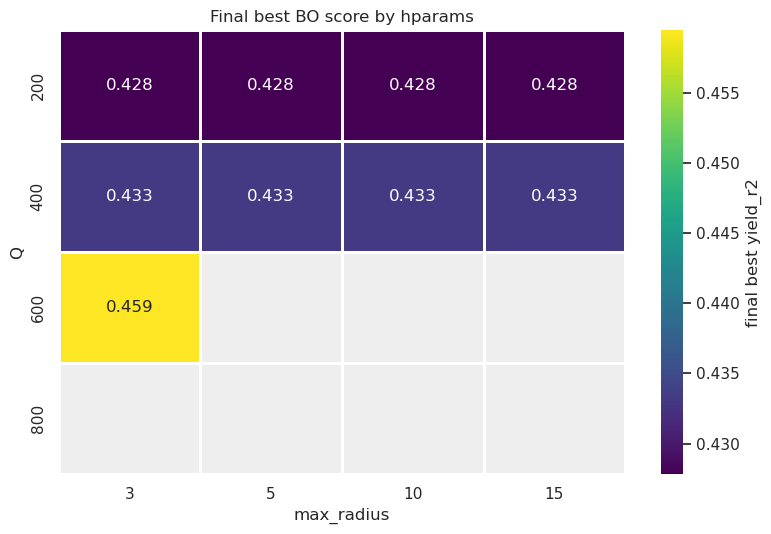

Saved -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/final_best_heatmap.png


In [5]:
heatmap_long = audit.copy()
heatmap_data = heatmap_long.pivot(index="Q", columns="max_radius", values="final_best").reindex(index=EXPECTED_QS, columns=EXPECTED_RADII)
annot = heatmap_data.copy().astype(object)
for q in heatmap_data.index:
    for r in heatmap_data.columns:
        val = heatmap_data.loc[q, r]
        annot.loc[q, r] = "missing" if pd.isna(val) else f"{val:.3f}"

cmap = plt.get_cmap("viridis").copy()
cmap.set_bad("#eeeeee")

fig, ax = plt.subplots(figsize=(8, 5.5))
sns.heatmap(
    heatmap_data,
    annot=annot,
    fmt="",
    cmap=cmap,
    linewidths=0.8,
    linecolor="white",
    cbar_kws={"label": f"final best {SCORE_METRIC}"},
    ax=ax,
)
ax.set_title("Final best BO score by hparams")
ax.set_xlabel("max_radius")
ax.set_ylabel("Q")
fig.tight_layout()
heatmap_path = REPORT_DIR / "final_best_heatmap.png"
fig.savefig(heatmap_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved -> {heatmap_path}")


## Convergence by hparam setting

Each facet fixes `Q`. Dashed lines show the per-iteration score and solid lines show running best. Identical trajectories are expected to overlap exactly.


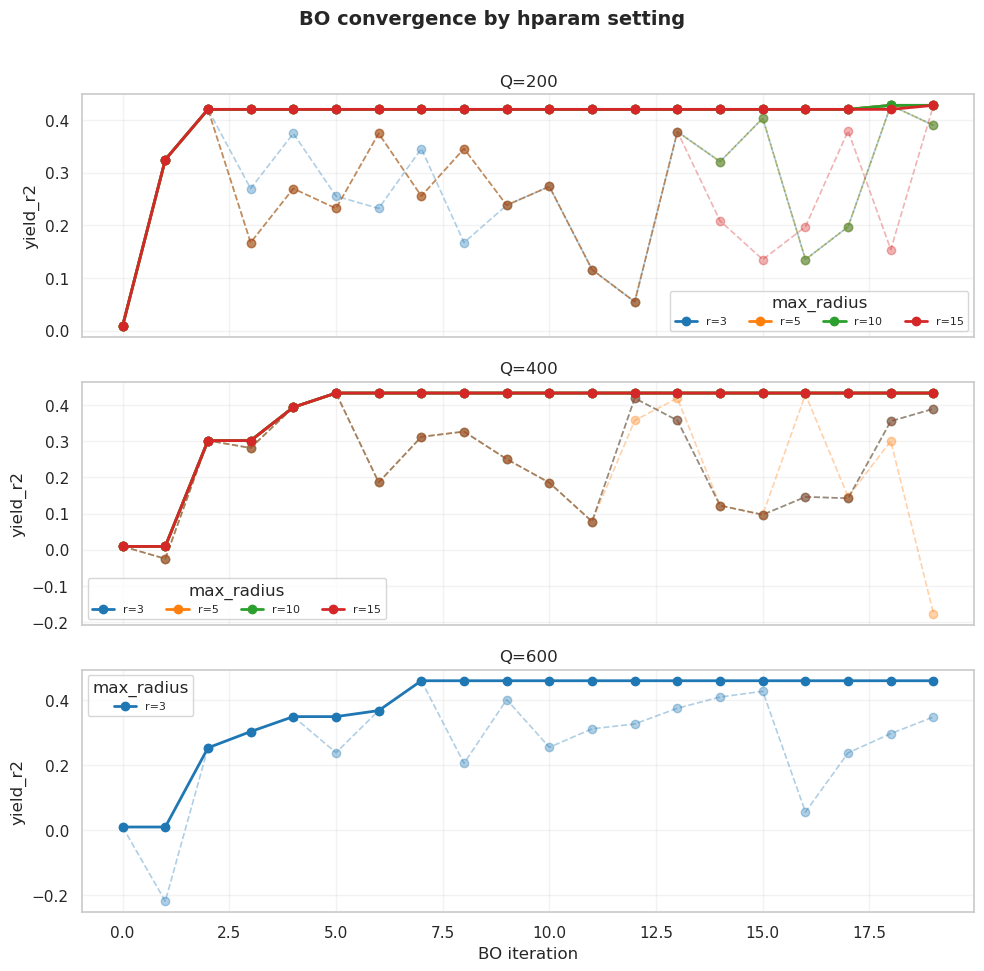

Saved -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/convergence_facets.png


In [6]:
radii_present = sorted(df["max_radius"].dropna().astype(int).unique())
palette = dict(zip(radii_present, sns.color_palette("tab10", n_colors=max(1, len(radii_present)))))
qs_present = sorted(df["Q"].dropna().astype(int).unique())

fig, axes = plt.subplots(len(qs_present), 1, figsize=(10, max(4, 3.2 * len(qs_present))), sharex=True)
if len(qs_present) == 1:
    axes = [axes]

for ax, q in zip(axes, qs_present):
    sub_q = df[df["Q"] == q]
    for r, sub in sub_q.groupby("max_radius", sort=True):
        sub = sub.sort_values("iteration")
        color = palette[int(r)]
        label = f"r={int(r)}"
        ax.plot(sub["iteration"], sub["score"], "o--", color=color, alpha=0.35, linewidth=1.2)
        ax.plot(sub["iteration"], sub["best_score"], "o-", color=color, linewidth=2.0, label=label)
    ax.set_title(f"Q={int(q)}")
    ax.set_ylabel(SCORE_METRIC)
    ax.grid(True, alpha=0.25)
    ax.legend(title="max_radius", ncols=min(4, len(radii_present)), fontsize=8)

axes[-1].set_xlabel("BO iteration")
fig.suptitle("BO convergence by hparam setting", y=1.01, fontsize=14, fontweight="bold")
fig.tight_layout()
conv_path = REPORT_DIR / "convergence_facets.png"
fig.savefig(conv_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved -> {conv_path}")


## BO mechanics diagnostics

These panels show the internal signals saved by `run_bo_experiment.py`: acquisition value, GP fit parameters, local observation count, subgraph size, restarts, and runtime. Null EI/GP values in early random/fallback iterations are left blank.


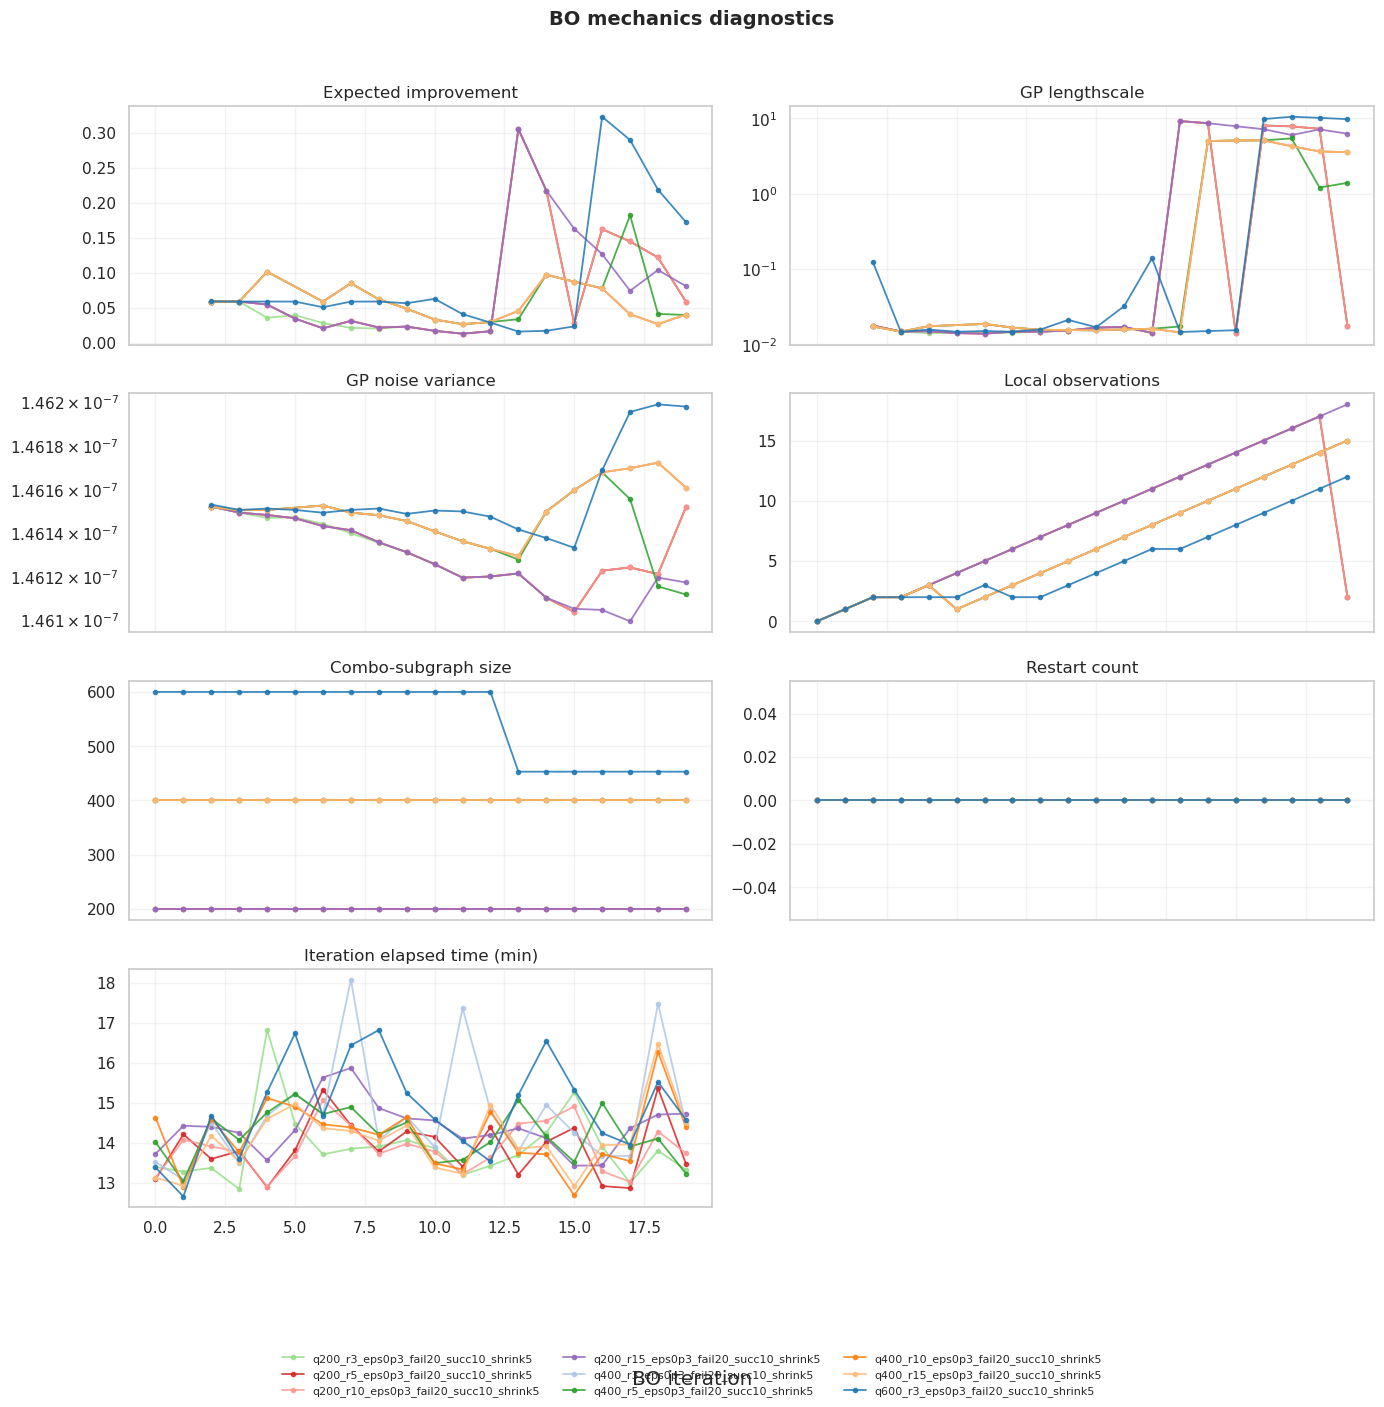

Saved -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/bo_mechanics_diagnostics.png


In [7]:
diagnostic_metrics = [
    ("ei_value", "Expected improvement", False),
    ("gp_lengthscale", "GP lengthscale", True),
    ("gp_noise_var", "GP noise variance", True),
    ("n_local_obs", "Local observations", False),
    ("subgraph_size", "Combo-subgraph size", False),
    ("n_restarts", "Restart count", False),
    ("elapsed_s", "Iteration elapsed time (min)", False),
]

fig, axes = plt.subplots(4, 2, figsize=(14, 14), sharex=True)
axes = axes.ravel()

line_palette = dict(zip(summary["run_label"], sns.color_palette("tab20", n_colors=max(1, len(summary)))))

for ax, (col, title, log_y) in zip(axes, diagnostic_metrics):
    for label, sub in df.groupby("run_label", sort=False):
        sub = sub.sort_values("iteration")
        y = sub[col].copy()
        if col == "elapsed_s":
            y = y / 60.0
        valid = y.notna()
        if not valid.any():
            continue
        ax.plot(
            sub.loc[valid, "iteration"],
            y.loc[valid],
            "o-",
            linewidth=1.3,
            markersize=3,
            alpha=0.85,
            color=line_palette[label],
            label=label,
        )
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    if log_y:
        ax.set_yscale("log")

axes[len(diagnostic_metrics)].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3, fontsize=8, frameon=False)
fig.supxlabel("BO iteration")
fig.suptitle("BO mechanics diagnostics", y=0.995, fontsize=14, fontweight="bold")
fig.tight_layout(rect=[0, 0.08, 1, 0.98])
mechanics_path = REPORT_DIR / "bo_mechanics_diagnostics.png"
fig.savefig(mechanics_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved -> {mechanics_path}")


## Subset movement and overlap

BO proposes a fresh 20-point subset each iteration. These plots quantify whether hparam settings explore different subsets or mostly follow the same one-swap neighborhood.


Subset movement CSV -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/subset_movement.csv


,run_label,seed,Q,max_radius,iteration,score,best_score,overlap_first_jaccard,overlap_prev_jaccard,swap_count_from_prev
0,q200_r3_eps0p3_fail20_succ10_shrink5,42,200,3,0,0.009282,0.009282,1.000000,NaN,NaN
1,q200_r3_eps0p3_fail20_succ10_shrink5,42,200,3,1,0.324873,0.324873,0.904762,0.904762,1.0
2,q200_r3_eps0p3_fail20_succ10_shrink5,42,200,3,2,0.420194,0.420194,0.818182,0.904762,1.0
3,q200_r3_eps0p3_fail20_succ10_shrink5,42,200,3,3,0.269924,0.420194,0.739130,0.904762,1.0
4,q200_r3_eps0p3_fail20_succ10_shrink5,42,200,3,4,0.374490,0.420194,0.739130,0.818182,2.0


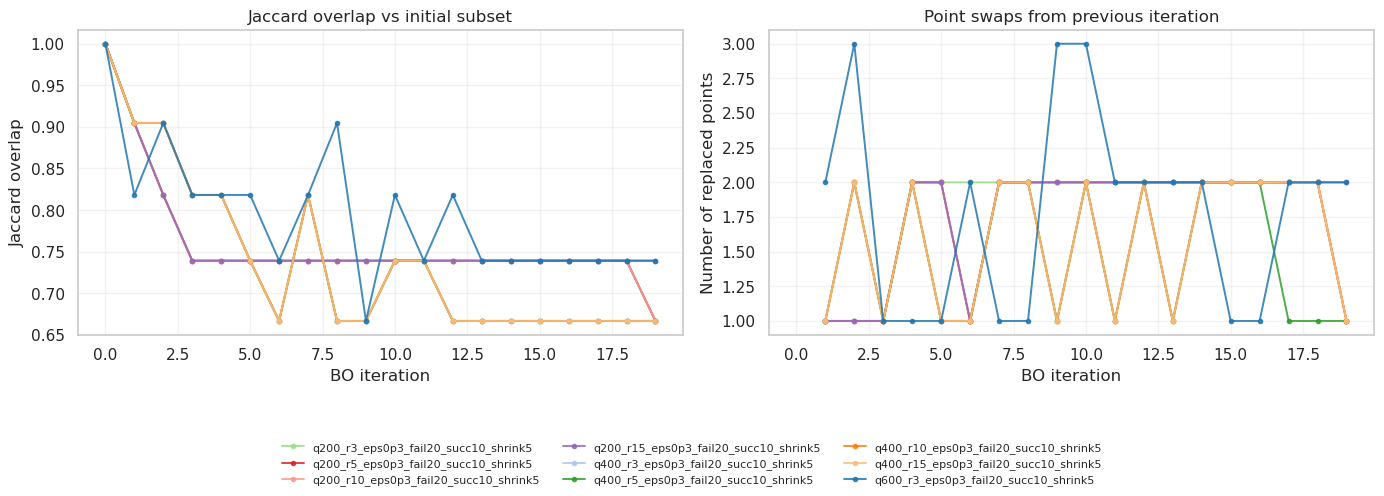

Saved -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/subset_behavior.png


In [8]:
def parse_points(value: str) -> set[str]:
    if pd.isna(value):
        return set()
    return set(str(x) for x in json.loads(value))


def jaccard(a: set[str], b: set[str]) -> float:
    if not a and not b:
        return 1.0
    return len(a & b) / len(a | b)

movement_rows = []
for label, sub in df.groupby("run_label", sort=False):
    sub = sub.sort_values("iteration")
    first = parse_points(sub.iloc[0]["selected_points_json"])
    prev = None
    for _, row in sub.iterrows():
        cur = parse_points(row["selected_points_json"])
        movement_rows.append({
            "run_label": label,
            "seed": int(row["seed"]),
            "Q": int(row["Q"]),
            "max_radius": int(row["max_radius"]),
            "iteration": int(row["iteration"]),
            "score": float(row["score"]),
            "best_score": float(row["best_score"]),
            "overlap_first_jaccard": jaccard(cur, first),
            "overlap_prev_jaccard": np.nan if prev is None else jaccard(cur, prev),
            "swap_count_from_prev": np.nan if prev is None else len(cur - prev),
        })
        prev = cur

movement = pd.DataFrame(movement_rows)
movement_path = REPORT_DIR / "subset_movement.csv"
movement.to_csv(movement_path, index=False)
print(f"Subset movement CSV -> {movement_path}")
display(movement.head())

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True)
for label, sub in movement.groupby("run_label", sort=False):
    color = line_palette.get(label)
    axes[0].plot(sub["iteration"], sub["overlap_first_jaccard"], "o-", linewidth=1.4, markersize=3, color=color, alpha=0.85, label=label)
    axes[1].plot(sub["iteration"], sub["swap_count_from_prev"], "o-", linewidth=1.4, markersize=3, color=color, alpha=0.85, label=label)

axes[0].set_title("Jaccard overlap vs initial subset")
axes[0].set_ylabel("Jaccard overlap")
axes[1].set_title("Point swaps from previous iteration")
axes[1].set_ylabel("Number of replaced points")
for ax in axes:
    ax.set_xlabel("BO iteration")
    ax.grid(True, alpha=0.25)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncols=3, fontsize=8, frameon=False)
fig.tight_layout(rect=[0, 0.18, 1, 1])
movement_fig_path = REPORT_DIR / "subset_behavior.png"
fig.savefig(movement_fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved -> {movement_fig_path}")


Pairwise exact subset identity CSV -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/pairwise_subset_identity.csv


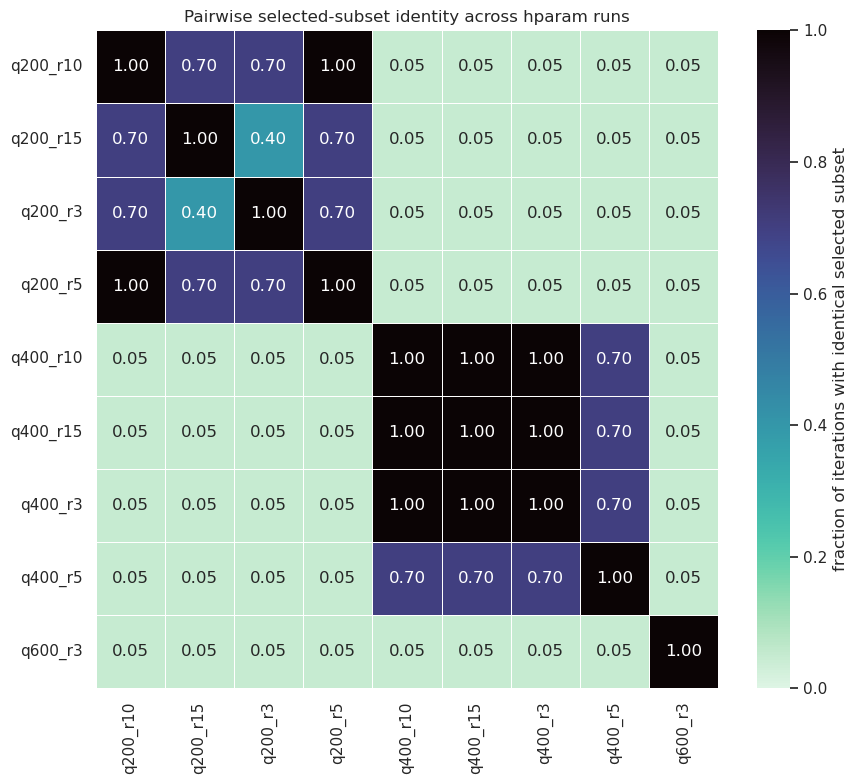

Saved -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/subset_identity_heatmap.png


In [9]:
sig_piv = df.pivot_table(index="iteration", columns="run_label", values="subset_signature", aggfunc="first").sort_index()
labels = list(sig_piv.columns)
identity = pd.DataFrame(np.eye(len(labels)), index=labels, columns=labels, dtype=float)
for a in labels:
    for b in labels:
        if a == b:
            identity.loc[a, b] = 1.0
            continue
        both = sig_piv[[a, b]].dropna()
        identity.loc[a, b] = float((both[a].to_numpy() == both[b].to_numpy()).mean()) if len(both) else np.nan

identity_path = REPORT_DIR / "pairwise_subset_identity.csv"
identity.to_csv(identity_path)
print(f"Pairwise exact subset identity CSV -> {identity_path}")

def short_label(label: str) -> str:
    parts = label.split("_")
    return "_".join(parts[:2])

fig, ax = plt.subplots(figsize=(9, 8))
sns.heatmap(
    identity,
    annot=True,
    fmt=".2f",
    cmap="mako_r",
    vmin=0,
    vmax=1,
    linewidths=0.4,
    linecolor="white",
    xticklabels=[short_label(x) for x in labels],
    yticklabels=[short_label(x) for x in labels],
    cbar_kws={"label": "fraction of iterations with identical selected subset"},
    ax=ax,
)
ax.set_title("Pairwise selected-subset identity across hparam runs")
fig.tight_layout()
identity_fig_path = REPORT_DIR / "subset_identity_heatmap.png"
fig.savefig(identity_fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Saved -> {identity_fig_path}")


## Spatial thumbnails

These thumbnails reuse existing per-iteration artifacts. They show the selected locations and feature coverage for the current best run plus representative `Q=200` and `Q=400` runs.


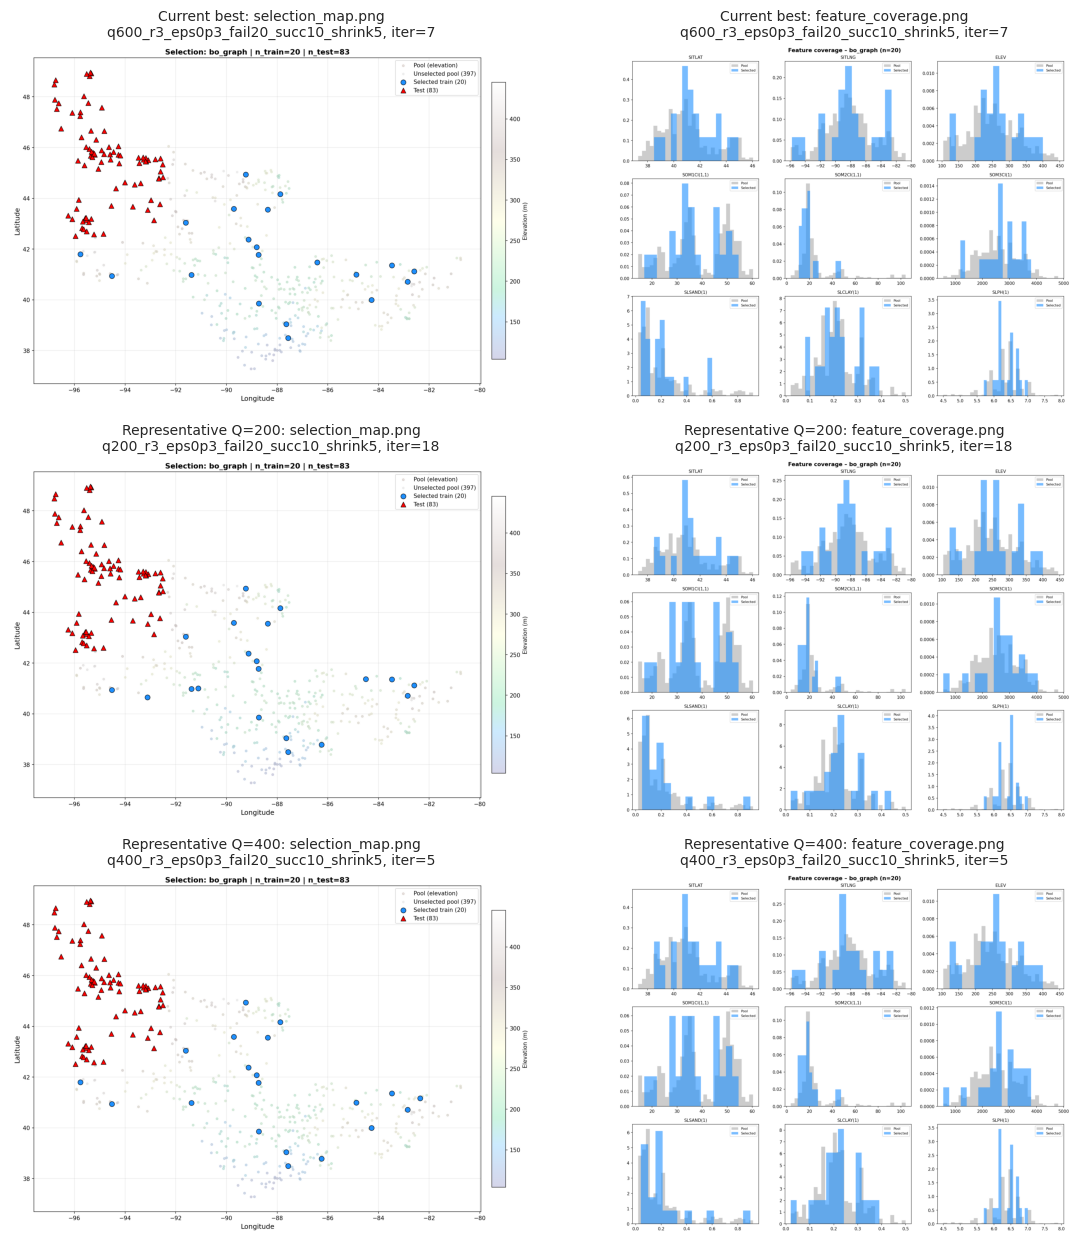

Thumbnail source CSV -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/spatial_thumbnail_sources.csv
Saved -> /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/spatial_thumbnails.png


,name,run_label,Q,max_radius,best_iter,iter_dir,selection_map_exists,feature_coverage_exists
0,Current best,q600_r3_eps0p3_fail20_succ10_shrink5,600,3,7,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q600_r3_eps0p3_fail20_suc...,True,True
1,Representative Q=200,q200_r3_eps0p3_fail20_succ10_shrink5,200,3,18,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q200_r3_eps0p3_fail20_suc...,True,True
2,Representative Q=400,q400_r3_eps0p3_fail20_succ10_shrink5,400,3,5,/projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/q400_r3_eps0p3_fail20_suc...,True,True


In [10]:
def pick_representative(q: int) -> pd.Series | None:
    candidates = summary[summary["Q"] == q]
    if candidates.empty:
        return None
    return candidates.sort_values(["final_best", "normalized_auc"], ascending=[False, False]).iloc[0]

rep_records = [("Current best", summary.iloc[0])]
for q in [200, 400]:
    rep = pick_representative(q)
    if rep is not None and rep["run_label"] not in {r[1]["run_label"] for r in rep_records}:
        rep_records.append((f"Representative Q={q}", rep))

fig, axes = plt.subplots(len(rep_records), 2, figsize=(12, 4.2 * len(rep_records)))
if len(rep_records) == 1:
    axes = np.array([axes])

thumb_rows = []
for row_idx, (name, rec) in enumerate(rep_records):
    run_label = rec["run_label"]
    seed = int(rec["seed"])
    n_points = int(df.loc[df["run_label"] == run_label, "n_points"].iloc[0])
    iter_id = int(rec["best_iter"])
    iter_dir = RESULT_ROOT / run_label / f"iter{iter_id}_n{n_points}_s{seed}"
    files = [iter_dir / "selection_map.png", iter_dir / "feature_coverage.png"]
    titles = ["selection_map.png", "feature_coverage.png"]
    thumb_rows.append({
        "name": name,
        "run_label": run_label,
        "Q": int(rec["Q"]),
        "max_radius": int(rec["max_radius"]),
        "best_iter": iter_id,
        "iter_dir": str(iter_dir),
        "selection_map_exists": files[0].exists(),
        "feature_coverage_exists": files[1].exists(),
    })

    for col_idx, (path, title) in enumerate(zip(files, titles)):
        ax = axes[row_idx, col_idx]
        if path.exists():
            ax.imshow(mpimg.imread(path))
            ax.set_title(f"{name}: {title}\n{run_label}, iter={iter_id}", fontsize=10)
        else:
            ax.text(0.5, 0.5, f"Missing\n{path}", ha="center", va="center", wrap=True)
            ax.set_title(f"{name}: {title}", fontsize=10)
        ax.axis("off")

thumbs = pd.DataFrame(thumb_rows)
thumbs_path = REPORT_DIR / "spatial_thumbnail_sources.csv"
thumbs.to_csv(thumbs_path, index=False)

fig.tight_layout()
thumb_fig_path = REPORT_DIR / "spatial_thumbnails.png"
fig.savefig(thumb_fig_path, dpi=180, bbox_inches="tight")
plt.show()
print(f"Thumbnail source CSV -> {thumbs_path}")
print(f"Saved -> {thumb_fig_path}")
display(thumbs)


## Interpretation notes

- The notebook ranks completed runs by `yield_r2`, matching the sweep objective.
- The available data are useful but incomplete: only one seed is present, and the planned grid currently has missing `Q=600` higher-radius runs plus all `Q=800` runs.
- In the current completed results, `Q=600, max_radius=3` is the best available setting, with final best `yield_r2` around 0.459.
- `max_radius` is an upper bound in `_build_combo_subgraph`; the builder stops once it reaches `Q`. The saved `subgraph_size` can show whether the search region hit the requested size, but the actual BFS hop count was printed to logs and was not saved in `bo_results.csv`.
- Several completed radius settings produce identical subset-signature trajectories, which suggests `max_radius` often did not change candidate availability for the observed BO path.


In [11]:
artifact_paths = [
    combined_path,
    audit_path,
    summary_path,
    heatmap_path,
    conv_path,
    mechanics_path,
    movement_path,
    movement_fig_path,
    identity_path,
    identity_fig_path,
    thumbs_path,
    thumb_fig_path,
]

print("Generated artifacts:")
for path in artifact_paths:
    print(f"- {path} ({'ok' if Path(path).exists() else 'missing'})")

print("\nSanity checks:")
print(f"- result CSV files: {len(result_paths)}")
print(f"- iteration rows: {len(df)}")
print(f"- missing hparam combinations: {n_missing}")
print(f"- initial subset signatures: {df[df['iteration'] == 0]['subset_signature'].nunique()}")


Generated artifacts:
- /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/combined_bo_hparam_results.csv (ok)
- /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/completion_audit.csv (ok)
- /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/summary_ranking.csv (ok)
- /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/final_best_heatmap.png (ok)
- /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/convergence_facets.png (ok)
- /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/bo_mechanics_diagnostics.png (ok)
- /projects/standard/kumarv/shared/dwij/daycent/output/selection/exp6_bo_hparam_n20/bo_graph/hparam_sweep_n20/subset_movement.csv (ok)
- /proj